In [1]:
import pandas as pd

# Load indian_market_news_newsdata_io.csv
indian_market_news_file = '/content/indian_market_news_newsdata_io.csv'
df_newsdata_io = pd.read_csv(indian_market_news_file)
print(f"Loaded {len(df_newsdata_io)} articles from {indian_market_news_file}")
print("Head of indian_market_news_newsdata_io.csv:")
print(df_newsdata_io.head())

print("\n" + "-"*50 + "\n")

# Load news_data.csv
news_data_file = '/content/news_data.csv'
df_news_data = pd.read_csv(news_data_file)
print(f"Loaded {len(df_news_data)} articles from {news_data_file}")
print("Head of news_data.csv:")
print(df_news_data.head())

Loaded 297 articles from /content/indian_market_news_newsdata_io.csv
Head of indian_market_news_newsdata_io.csv:
   S.No                                              Title  \
0     1  Ruckus in Assembly over Sunil Sharma’s charges...   
1     2  Stocks to Watch Today: Apollo Hospitals, Titan...   
2     3  Delhi, Beijing review ties, stress need to add...   
3     4  As AI, digital infra rewire global finance, In...   
4     5  Bank Strike (Feb 12): SBI Warns Of Disruption ...   

                     Source         Published At  \
0            dailyexcelsior  2026-02-10 22:37:41   
1              moneycontrol  2026-02-10 21:12:14   
2              tribuneindia  2026-02-10 21:08:52   
3  economictimes_indiatimes  2026-02-10 18:45:46   
4            english_jagran  2026-02-10 17:56:26   

                                                 URL  \
0  https://www.dailyexcelsior.com/ruckus-in-assem...   
1  https://www.moneycontrol.com/news/business/mar...   
2  https://www.tribuneindia.com/n

In [40]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download necessary NLTK data if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("NLTK stopwords and WordNet corpus checked/downloaded.")

NLTK stopwords and WordNet corpus checked/downloaded.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [41]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text) or text == '':
        return ""
    # Lowercase the text
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize the text
    words = text.split()
    # Remove stopwords and lemmatize
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join the cleaned words back into a string
    return ' '.join(cleaned_words)

# Apply the cleaning function to 'Title' and 'Description' columns
df_newsdata_io['Cleaned_Title'] = df_newsdata_io['Title'].apply(clean_text)
df_newsdata_io['Cleaned_Description'] = df_newsdata_io['Description'].apply(clean_text)

print("Text cleaning applied to 'Title' and 'Description' columns of df_newsdata_io.")
print("Displaying head of df_newsdata_io with new cleaned columns:")
print(df_newsdata_io[['Title', 'Cleaned_Title', 'Description', 'Cleaned_Description']].head())

Text cleaning applied to 'Title' and 'Description' columns of df_newsdata_io.
Displaying head of df_newsdata_io with new cleaned columns:
                                               Title  \
0  Ruckus in Assembly over Sunil Sharma’s charges...   
1  Stocks to Watch Today: Apollo Hospitals, Titan...   
2  Delhi, Beijing review ties, stress need to add...   
3  As AI, digital infra rewire global finance, In...   
4  Bank Strike (Feb 12): SBI Warns Of Disruption ...   

                                       Cleaned_Title  \
0         ruckus assembly sunil sharma’s charge govt   
1  stock watch today apollo hospital titan ather ...   
2  delhi beijing review tie stress need address ‘...   
3  ai digital infra rewire global finance india r...   
4  bank strike feb 12 sbi warns disruption nation...   

                                         Description  \
0  LoP snubs agitating NC MLAs Nishikant Khajuria...   
1  Stocks to Watch, 11 Feb: Stocks like Titan Com...   
2  India and China d

In [42]:
import sys
!{sys.executable} -m pip install spacy
!{sys.executable} -m spacy download en_core_web_sm

print("spaCy installed and 'en_core_web_sm' model downloaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 122.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy installed and 'en_core_web_sm' model downloaded.


In [43]:
import spacy

# Load the English language model
try:
    nlp = spacy.load('en_core_web_sm')
    print("spaCy 'en_core_web_sm' model loaded successfully.")
except OSError:
    print("spaCy 'en_core_web_sm' model not found. Please ensure it's downloaded.")
    print("You might need to run: python -m spacy download en_core_web_sm")
    # Fallback or exit if model is crucial
    nlp = None # Set to None to handle cases where the model isn't loaded

def extract_entities(text):
    if nlp is None or pd.isna(text) or text == '':
        return {}
    doc = nlp(text)
    entities = {
        'ORG': [], # Organizations
        'PERSON': [], # People, including fictional
        'GPE': [], # Geopolitical entities, i.e. countries, cities, states
        'LOC': [], # Non-GPE locations, e.g. mountain ranges, bodies of water
        'MONEY': [], # Monetary values, including unit
        'PERCENT': [], # Percentage, including "%"
        'DATE': [], # Absolute or relative dates or periods
        'TIME': [], # Times smaller than a day
        'PRODUCT': [], # Objects, vehicles, foods, etc. (not services)
        'EVENT': [], # Named hurricanes, battles, wars, sports events, etc.
        'NORP': [] # Nationalities, religious or political groups
    }
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text)
    # Remove duplicates from lists of entities
    for key in entities:
        entities[key] = list(set(entities[key]))
    return entities

# Apply NER to the cleaned title and description columns
df_newsdata_io['Title_Entities'] = df_newsdata_io['Cleaned_Title'].apply(extract_entities)
df_newsdata_io['Description_Entities'] = df_newsdata_io['Cleaned_Description'].apply(extract_entities)

print("Named Entity Recognition applied to 'Cleaned_Title' and 'Cleaned_Description' columns.")
print("Displaying head of df_newsdata_io with new entity columns:")
print(df_newsdata_io[['Cleaned_Title', 'Title_Entities', 'Cleaned_Description', 'Description_Entities']].head())

spaCy 'en_core_web_sm' model loaded successfully.
Named Entity Recognition applied to 'Cleaned_Title' and 'Cleaned_Description' columns.
Displaying head of df_newsdata_io with new entity columns:
                                       Cleaned_Title  \
0         ruckus assembly sunil sharma’s charge govt   
1  stock watch today apollo hospital titan ather ...   
2  delhi beijing review tie stress need address ‘...   
3  ai digital infra rewire global finance india r...   
4  bank strike feb 12 sbi warns disruption nation...   

                                      Title_Entities  \
0  {'ORG': [], 'PERSON': [], 'GPE': [], 'LOC': []...   
1  {'ORG': ['apollo hospital'], 'PERSON': [], 'GP...   
2  {'ORG': [], 'PERSON': [], 'GPE': ['beijing'], ...   
3  {'ORG': [], 'PERSON': [], 'GPE': ['india'], 'L...   
4  {'ORG': [], 'PERSON': [], 'GPE': [], 'LOC': []...   

                                 Cleaned_Description  \
0  lop snub agitating nc mlas nishikant khajuria ...   
1  stock watch 11 

In [44]:
!pip install transformers

In [46]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load pre-trained FinBERT model and tokenizer
model_name = 'ProsusAI/finbert'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print(f"FinBERT model '{model_name}' and tokenizer loaded successfully.")

def analyze_finbert_sentiment(text):
    if pd.isna(text) or text == '':
        return "neutral", 0.0

    # FinBERT is trained on English, so combining cleaned text is suitable.
    # Truncate text to avoid exceeding model's max token limit (typically 512)
    max_length = 512
    if len(text.split()) > max_length:
        text = ' '.join(text.split()[:max_length])

    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    outputs = model(**inputs)

    # Apply softmax to get probabilities
    probabilities = torch.softmax(outputs.logits, dim=1)[0]

    # Get the sentiment label and confidence
    sentiment_labels = ['positive', 'negative', 'neutral'] # FinBERT's output order

    # For ProsusAI/finbert, the order is typically 'positive', 'negative', 'neutral'
    # Let's verify the model's id2label mapping or rely on common knowledge for this specific model
    # If model.config.id2label is available, it's more robust:
    if hasattr(model.config, 'id2label'):
        sentiment_labels = [model.config.id2label[i] for i in range(len(model.config.id2label))]

    predicted_sentiment_idx = torch.argmax(probabilities).item()
    sentiment_label = sentiment_labels[predicted_sentiment_idx]
    confidence_score = probabilities[predicted_sentiment_idx].item()

    return sentiment_label, confidence_score

# Combine cleaned title and description for a more comprehensive analysis
df_newsdata_io['Combined_Cleaned_Text'] = df_newsdata_io['Cleaned_Title'] + " " + df_newsdata_io['Cleaned_Description']

# Apply the sentiment analysis function
df_newsdata_io[['FinBERT_Sentiment', 'FinBERT_Confidence']] = df_newsdata_io['Combined_Cleaned_Text'].apply(lambda x: pd.Series(analyze_finbert_sentiment(x)))

print("FinBERT sentiment analysis applied to df_newsdata_io.")
print("Displaying head of df_newsdata_io with new FinBERT sentiment columns:")
print(df_newsdata_io[['Cleaned_Title', 'Cleaned_Description', 'FinBERT_Sentiment', 'FinBERT_Confidence']].head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT model 'ProsusAI/finbert' and tokenizer loaded successfully.
FinBERT sentiment analysis applied to df_newsdata_io.
Displaying head of df_newsdata_io with new FinBERT sentiment columns:
                                       Cleaned_Title  \
0         ruckus assembly sunil sharma’s charge govt   
1  stock watch today apollo hospital titan ather ...   
2  delhi beijing review tie stress need address ‘...   
3  ai digital infra rewire global finance india r...   
4  bank strike feb 12 sbi warns disruption nation...   

                                 Cleaned_Description FinBERT_Sentiment  \
0  lop snub agitating nc mlas nishikant khajuria ...          negative   
1  stock watch 11 feb stock like titan company ap...           neutral   
2  india china discussed bilateral tie emphasizin...           neutral   
3  global financial system undergoing major shift...          positive   
4  bank strike february 12sbi bank servicesidbi b...          negative   

   FinBERT_Confidence  
0 

In [49]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import shutil # Import shutil for rmtree

# Ensure matplotlib base is imported for get_cachedir()
import matplotlib # Explicitly import matplotlib

# Install Noto Color Emoji font for better emoji support
# This requires system-level installation in some environments (like Colab).
!sudo apt-get install -y fonts-noto-color-emoji

# Clear matplotlib's font cache
# This is crucial for matplotlib to recognize newly installed fonts.
# The correct way to get the cache directory is via the top-level matplotlib module.
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    # Using shutil.rmtree is safer and more robust than os.system(f'rm -rf {cache_dir}')
    shutil.rmtree(cache_dir)
    print(f"Cleared font cache at: {cache_dir}")

# Rebuild the font cache
# The fontManager is part of the fm module, and clear() will remove the cache.
# findfont() will then trigger a rebuild on demand. Or directly rebuild using an internal method.
fm._load_fontmanager(try_read_cache=False) # Internal function to force rebuild without cache

# Configure matplotlib to use a font that supports emojis
# Check if 'Noto Color Emoji' is available AFTER rebuilding the cache
if 'Noto Color Emoji' in [f.name for f in fm.fontManager.ttflist]:
    plt.rcParams['font.family'] = 'sans-serif'
    # Add 'Noto Color Emoji' as the first sans-serif font, followed by common system fonts.
    plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'Arial Unicode MS', 'Liberation Sans']
    print("Matplotlib configured to use Noto Color Emoji.")
else:
    print("Noto Color Emoji not found after rebuild, using default sans-serif (emojis might not display).")
    # Fallback to common sans-serif fonts if Noto Color Emoji is not available
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'Liberation Sans']

print("Matplotlib font configuration complete.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-color-emoji is already the newest version (2.047-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Cleared font cache at: /root/.cache/matplotlib


Noto Color Emoji not found after rebuild, using default sans-serif (emojis might not display).
Matplotlib font configuration complete.



GENERATING FINBERT SENTIMENT SUMMARY

OVERALL FINBERT SENTIMENT SUMMARY
────────────────────────────
Total Articles Analyzed by FinBERT: 297

POSITIVE: 115 (38.7%)
   Average Confidence: 83.4%

NEUTRAL:  144 (48.5%)
   Average Confidence: 79.8%

NEGATIVE: 38 (12.8%)
   Average Confidence: 77.0%

OVERALL FINBERT SENTIMENT SCORE: 0.26
AVERAGE CONFIDENCE: 80.8%


GENERATING FINBERT SENTIMENT VISUALIZATIONS


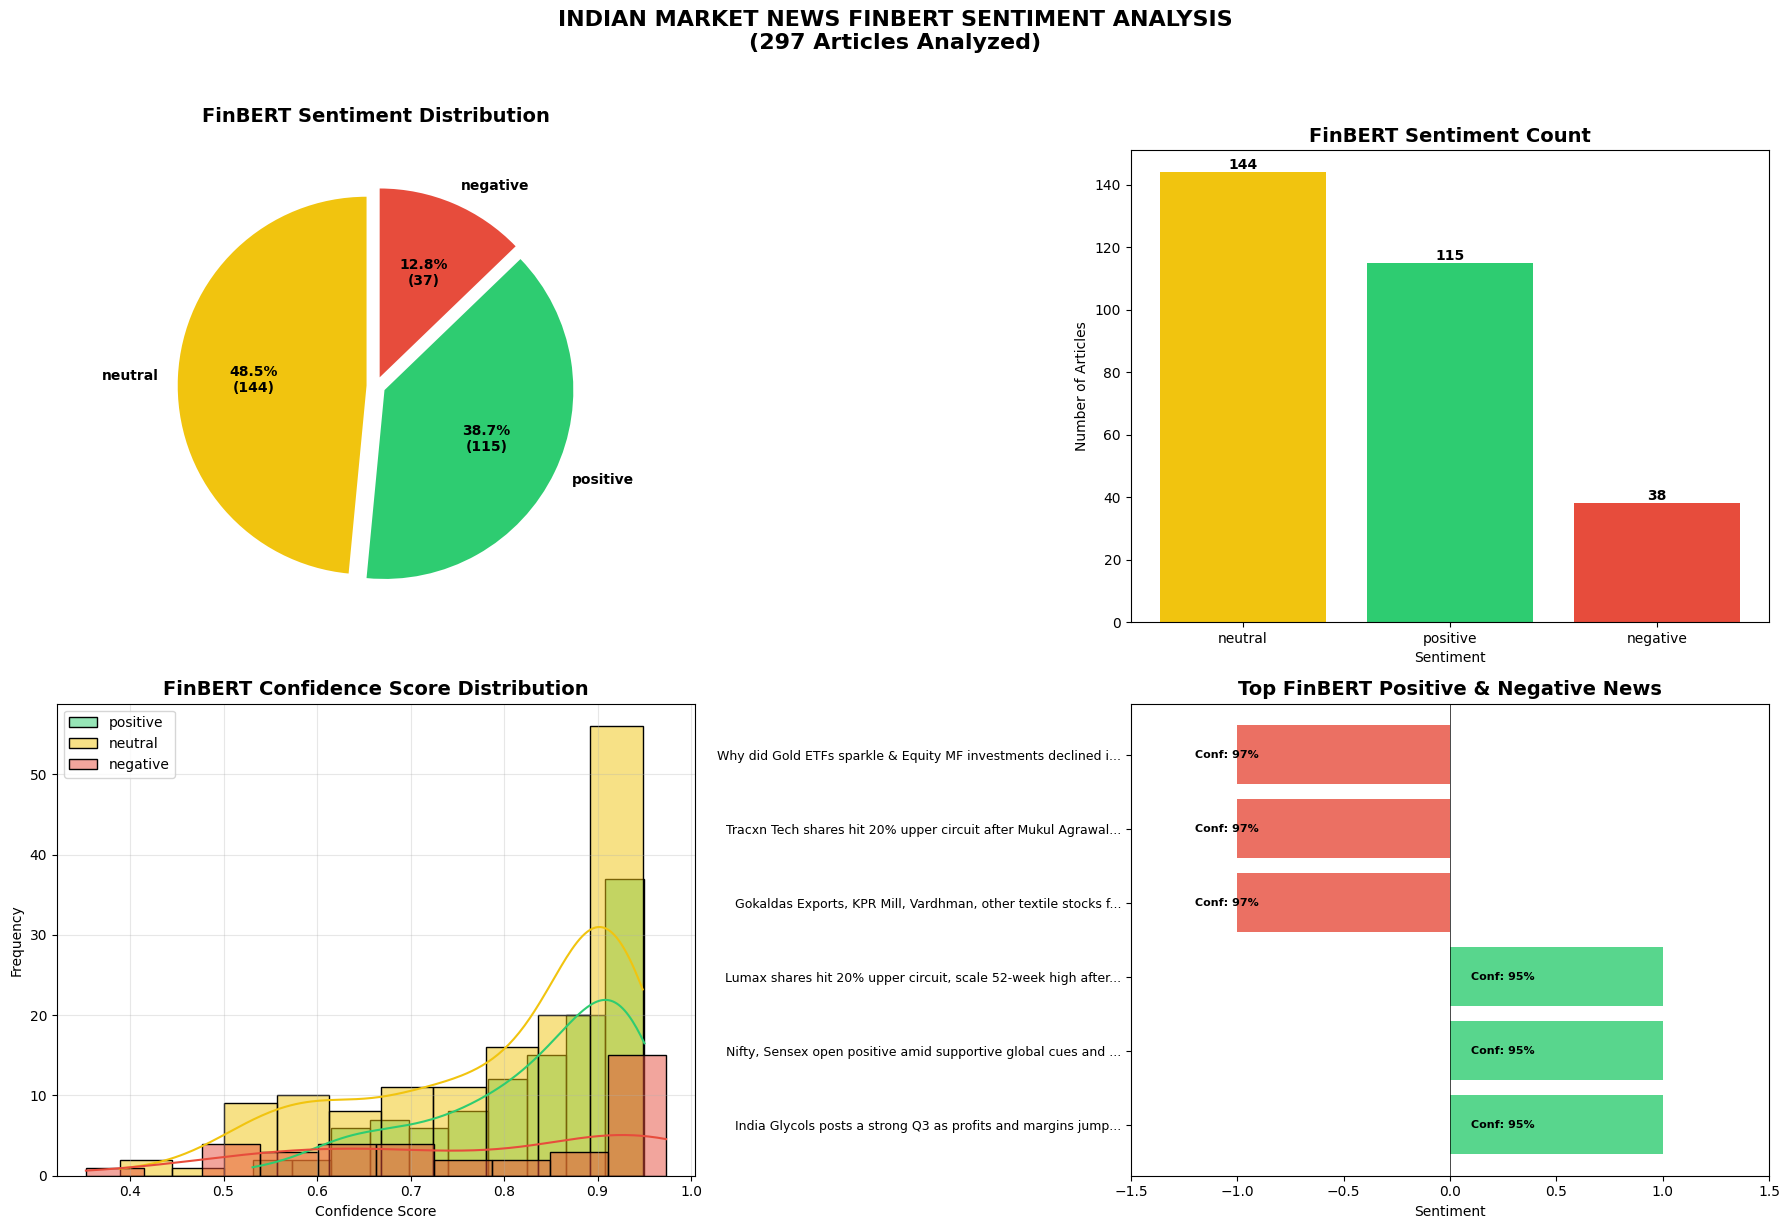


GENERATING FINBERT DETAILED REPORT

╔══════════════════════════════════════════════════════════════════════════════════════╗
║                INDIAN MARKET NEWS FINBERT SENTIMENT ANALYSIS REPORT                  ║
║                                Generated from CSV Data                               ║
╚═══════════════════════════════════════════════════════════════════════════════════════

EXECUTIVE SUMMARY (FinBERT)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
• Analysis Date: 2026-02-11 12:40:20
• Total Articles Analyzed by FinBERT: 297
• Overall FinBERT Sentiment Score: +0.259
• Average Confidence: 80.8%

FINBERT SENTIMENT DISTRIBUTION
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
POSITIVE :  115 articles ( 38.7%)
   → Avg Confidence: 83.4%

NEUTRAL  :  144 articles ( 48.5%)
   → Avg Confidence: 79.8%

NEGATIVE :   38 articles ( 12.8

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datetime import datetime
import pandas as pd

# Prepare sentiment scores for FinBERT analysis
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df_newsdata_io['FinBERT_Sentiment_Score'] = df_newsdata_io['FinBERT_Sentiment'].map(sentiment_map)

print("\nGENERATING FINBERT SENTIMENT SUMMARY")
print("="*60)

# Overall sentiment statistics for FinBERT
total_analyzed_finbert = len(df_newsdata_io)
if total_analyzed_finbert == 0:
    print("No articles analyzed by FinBERT. Skipping summary generation.")
else:
    positive_count_finbert = len(df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'positive'])
    neutral_count_finbert = len(df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'neutral'])
    negative_count_finbert = len(df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'negative'])

    avg_conf_positive_finbert_str = f"{df_newsdata_io[df_newsdata_io['FinBERT_Sentiment']=='positive']['FinBERT_Confidence'].mean():.1%}" if positive_count_finbert > 0 else 'N/A'
    avg_conf_neutral_finbert_str = f"{df_newsdata_io[df_newsdata_io['FinBERT_Sentiment']=='neutral']['FinBERT_Confidence'].mean():.1%}" if neutral_count_finbert > 0 else 'N/A'
    avg_conf_negative_finbert_str = f"{df_newsdata_io[df_newsdata_io['FinBERT_Sentiment']=='negative']['FinBERT_Confidence'].mean():.1%}" if negative_count_finbert > 0 else 'N/A'

    print(f"""
OVERALL FINBERT SENTIMENT SUMMARY
────────────────────────────
Total Articles Analyzed by FinBERT: {total_analyzed_finbert}

POSITIVE: {positive_count_finbert} ({positive_count_finbert/total_analyzed_finbert*100:.1f}%)
   Average Confidence: {avg_conf_positive_finbert_str}

NEUTRAL:  {neutral_count_finbert} ({neutral_count_finbert/total_analyzed_finbert*100:.1f}%)
   Average Confidence: {avg_conf_neutral_finbert_str}

NEGATIVE: {negative_count_finbert} ({negative_count_finbert/total_analyzed_finbert*100:.1f}%)
   Average Confidence: {avg_conf_negative_finbert_str}

OVERALL FINBERT SENTIMENT SCORE: {df_newsdata_io['FinBERT_Sentiment_Score'].mean():.2f}
AVERAGE CONFIDENCE: {df_newsdata_io['FinBERT_Confidence'].mean():.1%}
""")

print("\nGENERATING FINBERT SENTIMENT VISUALIZATIONS")
print("="*60)

if total_analyzed_finbert == 0:
    print("No articles analyzed by FinBERT. Skipping visualizations.")
else:
    plt.style.use('default')
    sns.set_palette("viridis")
    fig = plt.figure(figsize=(18, 12))

    # Configure matplotlib to use fonts that support emojis
    # Prioritize DejaVu Sans for text, then Noto Color Emoji for fallback (emojis)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Noto Color Emoji', 'Arial Unicode MS', 'Liberation Sans']

    # 1. FinBERT Sentiment Distribution Pie Chart
    ax1 = plt.subplot(2, 2, 1)
    sentiment_counts_finbert = df_newsdata_io['FinBERT_Sentiment'].value_counts()
    colors = {'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'}
    colors_list = [colors.get(sent, '#95a5a6') for sent in sentiment_counts_finbert.index]

    ax1.pie(sentiment_counts_finbert.values,
            labels=sentiment_counts_finbert.index,
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct*total_analyzed_finbert/100)})',
            colors=colors_list,
            startangle=90,
            explode=[0.05] * len(sentiment_counts_finbert),
            textprops={'fontsize': 10, 'fontweight': 'bold'})
    ax1.set_title('FinBERT Sentiment Distribution', fontsize=14, fontweight='bold', pad=20)

    # 2. FinBERT Sentiment Bar Chart
    ax2 = plt.subplot(2, 2, 2)
    bars = ax2.bar(sentiment_counts_finbert.index, sentiment_counts_finbert.values,
                   color=[colors.get(x, '#95a5a6') for x in sentiment_counts_finbert.index])
    ax2.set_title('FinBERT Sentiment Count', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Sentiment')
    ax2.set_ylabel('Number of Articles')
    ax2.tick_params(axis='x', rotation=0)
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    # 3. FinBERT Confidence Distribution
    ax3 = plt.subplot(2, 2, 3)
    for sentiment in ['positive', 'neutral', 'negative']:
        subset = df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == sentiment]
        if len(subset) > 0:
            sns.histplot(subset['FinBERT_Confidence'], bins=10, alpha=0.5, label=sentiment, color=colors.get(sentiment), ax=ax3, kde=True)
    ax3.set_title('FinBERT Confidence Score Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Confidence Score')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Top Positive & Negative News by FinBERT Confidence
    ax4 = plt.subplot(2, 2, 4)
    top_positive_finbert = df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'positive'].nlargest(3, 'FinBERT_Confidence')
    top_negative_finbert = df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'negative'].nlargest(3, 'FinBERT_Confidence')

    sentiment_values_finbert = []
    sentiment_labels_finbert = []
    sentiment_colors_finbert = []
    conf_scores_finbert = []

    for _, row in top_positive_finbert.iterrows():
        sentiment_values_finbert.append(1)
        sentiment_colors_finbert.append(colors['positive'])
        sentiment_labels_finbert.append(f"{row['Title'][:60]}...") # Removed emoji
        conf_scores_finbert.append(row['FinBERT_Confidence'])

    for _, row in top_negative_finbert.iterrows():
        sentiment_values_finbert.append(-1)
        sentiment_colors_finbert.append(colors['negative'])
        sentiment_labels_finbert.append(f"{row['Title'][:60]}...") # Removed emoji
        conf_scores_finbert.append(row['FinBERT_Confidence'])

    if len(sentiment_values_finbert) > 0:
        y_pos = range(len(sentiment_values_finbert))
        bars = ax4.barh(y_pos, sentiment_values_finbert, color=sentiment_colors_finbert, alpha=0.8)
        ax4.set_yticks(y_pos)
        ax4.set_yticklabels(sentiment_labels_finbert, fontsize=9)
        ax4.set_title('Top FinBERT Positive & Negative News', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Sentiment')
        ax4.set_xlim(-1.5, 1.5)
        ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

        for i, bar in enumerate(bars):
            x_pos = 0.1 if sentiment_values_finbert[i] == 1 else -0.9
            ax4.text(x_pos, bar.get_y() + bar.get_height()/2,
                    f'Conf: {conf_scores_finbert[i]:.0%}', va='center', ha='left' if sentiment_values_finbert[i] == 1 else 'right',
                    fontsize=8, fontweight='bold', color='black')
    else:
        ax4.text(0.5, 0.5, 'No FinBERT positive or negative news to display', horizontalalignment='center', verticalalignment='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    plt.suptitle(f'INDIAN MARKET NEWS FINBERT SENTIMENT ANALYSIS\n({total_analyzed_finbert} Articles Analyzed)',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('indian_market_finbert_sentiment_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nGENERATING FINBERT DETAILED REPORT")
print("="*60)

if total_analyzed_finbert == 0:
    report_finbert = "No articles were successfully analyzed by FinBERT. Detailed report cannot be generated."
    print(report_finbert)
else:
    report_finbert = f"""
╔══════════════════════════════════════════════════════════════════════════════════════╗
║                INDIAN MARKET NEWS FINBERT SENTIMENT ANALYSIS REPORT                  ║
║                                Generated from CSV Data                               ║
╚═══════════════════════════════════════════════════════════════════════════════════════

EXECUTIVE SUMMARY (FinBERT)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
• Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
• Total Articles Analyzed by FinBERT: {len(df_newsdata_io):,}
• Overall FinBERT Sentiment Score: {df_newsdata_io['FinBERT_Sentiment_Score'].mean():+.3f}
• Average Confidence: {df_newsdata_io['FinBERT_Confidence'].mean():.1%}

FINBERT SENTIMENT DISTRIBUTION
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
POSITIVE : {positive_count_finbert:4} articles ({positive_count_finbert/total_analyzed_finbert*100:5.1f}%)
   → Avg Confidence: {avg_conf_positive_finbert_str}

NEUTRAL  : {neutral_count_finbert:4} articles ({neutral_count_finbert/total_analyzed_finbert*100:5.1f}%)
   → Avg Confidence: {avg_conf_neutral_finbert_str}

NEGATIVE : {negative_count_finbert:4} articles ({negative_count_finbert/total_analyzed_finbert*100:5.1f}%)
   → Avg Confidence: {avg_conf_negative_finbert_str}

TOP FINBERT POSITIVE NEWS HEADLINES
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────"""

    for idx, row in df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'positive'].nlargest(3, 'FinBERT_Confidence').iterrows():
        report_finbert += f"\n[{(row['FinBERT_Confidence']):.0%}% conf] {row['Title'][:120]}..."

    report_finbert += f"""

TOP FINBERT NEGATIVE NEWS HEADLINES
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────"""

    for idx, row in df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'negative'].nlargest(3, 'FinBERT_Confidence').iterrows():
        report_finbert += f"\n[{(row['FinBERT_Confidence']):.0%}% conf] {row['Title'][:120]}..."

    report_finbert += f"""

KEY FINBERT INSIGHTS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1. Overall Market Sentiment (FinBERT): {'BULLISH' if df_newsdata_io['FinBERT_Sentiment_Score'].mean() > 0.1 else 'BEARISH' if df_newsdata_io['FinBERT_Sentiment_Score'].mean() < -0.1 else 'NEUTRAL'}

STATISTICAL SUMMARY (FinBERT)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Sentiment Score:
  • Mean:     {df_newsdata_io['FinBERT_Sentiment_Score'].mean():+.3f}
  • Median:   {df_newsdata_io['FinBERT_Sentiment_Score'].median():+.3f}
  • Std Dev:  {df_newsdata_io['FinBERT_Sentiment_Score'].std():.3f}
  • Range:    {df_newsdata_io['FinBERT_Sentiment_Score'].min():+.3f} to {df_newsdata_io['FinBERT_Sentiment_Score'].max():+.3f}

Confidence Score:
  • Mean:     {df_newsdata_io['FinBERT_Confidence'].mean():.1%}
  • Median:   {df_newsdata_io['FinBERT_Confidence'].median():.1%}
  • Std Dev:  {df_newsdata_io['FinBERT_Confidence'].std():.1%}

REPORT GENERATED
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
• Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
• Visualization: indian_market_finbert_sentiment_analysis.png
• Report File: finbert_sentiment_analysis_report.txt

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                              END OF FINBERT REPORT
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
"""

    print(report_finbert)

print("\nSAVING FINBERT RESULTS")
print("="*60)

if total_analyzed_finbert == 0:
    print("No articles were successfully analyzed by FinBERT. Skipping saving results.")
else:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    finbert_sentiment_csv = f'finbert_sentiment_analysis_results_{timestamp}.csv'
    df_newsdata_io.to_csv(finbert_sentiment_csv, index=False)
    print(f"FinBERT sentiment results saved to: {finbert_sentiment_csv}")

    finbert_report_file = f'finbert_sentiment_analysis_report_{timestamp}.txt'
    with open(finbert_report_file, 'w', encoding='utf-8') as f:
        f.write(report_finbert)
    print(f"FinBERT report saved to: {finbert_report_file}")

    finbert_summary_stats = {
        'total_articles_analyzed_finbert': len(df_newsdata_io),
        'positive_count_finbert': int(positive_count_finbert),
        'neutral_count_finbert': int(neutral_count_finbert),
        'negative_count_finbert': int(negative_count_finbert),
        'avg_sentiment_finbert': float(df_newsdata_io['FinBERT_Sentiment_Score'].mean()),
        'avg_confidence_finbert': float(df_newsdata_io['FinBERT_Confidence'].mean()),
        'sentiment_distribution_finbert': df_newsdata_io['FinBERT_Sentiment'].value_counts().to_dict(),
        'analysis_timestamp': datetime.now().isoformat()
    }

    finbert_summary_json = f'finbert_sentiment_summary_{timestamp}.json'
    with open(finbert_summary_json, 'w') as f:
        json.dump(finbert_summary_stats, f, indent=2, default=str)
    print(f"FinBERT summary statistics saved to: {finbert_summary_json}")

print("\n" + "─"*50)
print("  FINBERT SENTIMENT ANALYSIS COMPLETED SUCCESSFULLY!  ")
print("─"*50 + "\n")

In [60]:
import numpy as np
import pandas as pd
from datetime import timedelta

# Ensure df_newsdata_io is a DataFrame (it should be from previous steps)
if 'df_newsdata_io' not in locals():
    print("Error: df_newsdata_io not found. Please ensure previous steps ran successfully.")
    # Load a dummy dataframe to prevent errors if running standalone for testing
    df_newsdata_io = pd.DataFrame({'Published At': [datetime.now(), datetime.now() - timedelta(days=5)]})

# Convert 'Published At' to datetime if not already
df_newsdata_io['Published At'] = pd.to_datetime(df_newsdata_io['Published At'], errors='coerce')

# Drop rows where 'Published At' is NaT after conversion
df_newsdata_io_cleaned = df_newsdata_io.dropna(subset=['Published At'])

# 2. Determine the date range for synthetic data generation
min_date = df_newsdata_io_cleaned['Published At'].min().normalize() if not df_newsdata_io_cleaned.empty else datetime.now().normalize() - timedelta(days=30)
max_date = df_newsdata_io_cleaned['Published At'].max().normalize() if not df_newsdata_io_cleaned.empty else datetime.now().normalize()

# Expand the date range
start_date = min_date - timedelta(days=10)
end_date = max_date + timedelta(days=10)

# 3. Create a list of dates within this expanded range
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Initialize lists to store data
market_data = []

# Initial values
initial_price = 1000.0
previous_close = initial_price

# ATR parameters
atr_period = 14
true_ranges = []

# 4. Generate synthetic market data for each date
for i, date in enumerate(dates):
    # Simulate daily price movements
    open_price = previous_close + np.random.uniform(-5, 5)
    high_price = open_price + np.random.uniform(0, 10)
    low_price = open_price - np.random.uniform(0, 10)
    close_price = open_price + np.random.uniform(-7, 7)

    # Ensure constraints
    if high_price < open_price: high_price = open_price
    if high_price < close_price: high_price = close_price
    if low_price > open_price: low_price = open_price
    if low_price > close_price: low_price = close_price

    # Ensure prices are positive
    open_price = max(0.01, open_price)
    high_price = max(0.01, high_price)
    low_price = max(0.01, low_price)
    close_price = max(0.01, close_price)

    # 5. Generate synthetic 'Volume' data
    volume = np.random.randint(100000, 5000000)

    # 6. Calculate the 'True Range'
    if i == 0: # First day, no previous close
        true_range = high_price - low_price
    else:
        true_range = max(high_price - low_price,
                           abs(high_price - previous_close),
                           abs(low_price - previous_close))
    true_ranges.append(true_range)

    # 7. Calculate the 'Average True Range (ATR)'
    if len(true_ranges) < atr_period:
        atr = np.nan # Not enough data for initial ATR
    else:
        atr = np.mean(true_ranges[-atr_period:])

    # 8. Generate synthetic 'Implied Volatility' values
    implied_volatility = np.random.uniform(0.1, 0.5)

    market_data.append({
        'Date': date,
        'Open': open_price,
        'High': high_price,
        'Low': low_price,
        'Close': close_price,
        'Volume': volume,
        'ATR': atr,
        'Implied_Volatility': implied_volatility
    })

    previous_close = close_price

# 9. Combine all generated data into a Pandas DataFrame
df_market_data = pd.DataFrame(market_data)

# 10. Print the head and information (`.info()`) of the `df_market_data` DataFrame
print("Generated Synthetic Market Data:")
print(df_market_data.head())
print("\n")
print(df_market_data.info())


Generated Synthetic Market Data:
        Date         Open         High         Low       Close   Volume  ATR  \
0 2026-01-30  1000.492267  1007.638226  993.890293  997.411341  4701020  NaN   
1 2026-01-31   997.954882  1004.072089  993.758881  994.423116  2264367  NaN   
2 2026-02-01   990.624762   994.043559  984.942960  984.942960  3821309  NaN   
3 2026-02-02   986.979538   991.721277  986.001197  986.862161  3602630  NaN   
4 2026-02-03   986.508899   993.006636  986.028310  992.796939  1741249  NaN   

   Implied_Volatility  
0            0.395159  
1            0.163459  
2            0.442184  
3            0.238522  
4            0.204357  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                22 non-null     datetime64[ns]
 1   Open                22 non-null     float64       
 2   High     

Average Daily Returns Around News Events:
   Days_Relative_to_Event  Daily_Return
0                      -3     -0.285214
1                      -2     -0.398260
2                      -1      0.060138
3                       0      0.096959
4                       1     -0.200048
5                       2      0.557300
6                       3     -0.040535


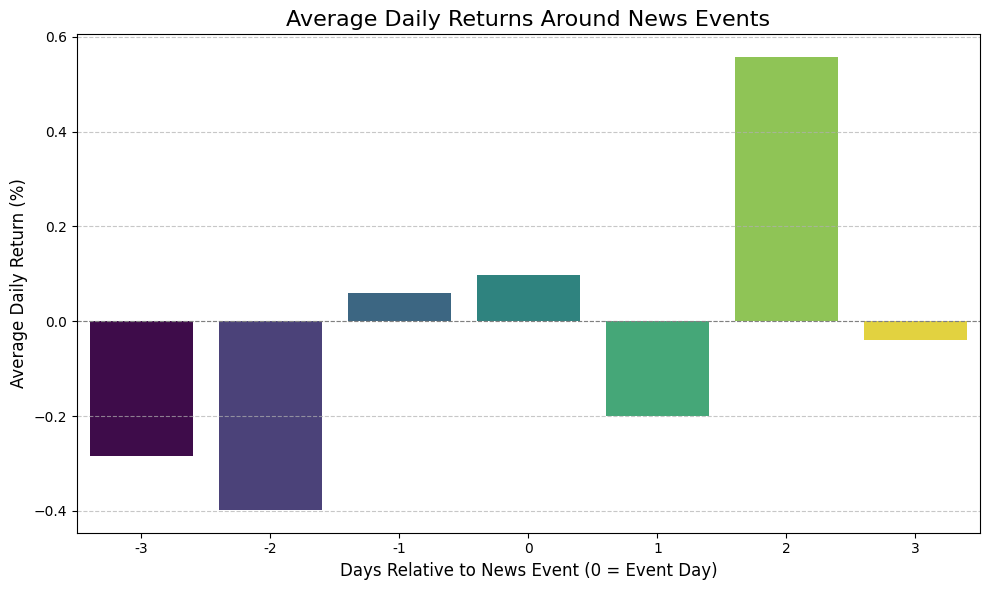

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Merge df_newsdata_io with df_market_data
# Rename 'Published At' in df_newsdata_io to 'Date' for easier merging if needed, or specify left_on/right_on
df_news_events = df_newsdata_io.copy()

# Merge df_news_events with df_market_data to link news dates to market data
# We'll merge on the 'Published At' column from news and 'Date' from market data
# We need a unique identifier for each news event to distinguish them if multiple news occur on the same day
df_news_events['event_id'] = df_news_events.index

# Create a list to store event study results
event_returns = []

# Loop through each news event to gather market data within the event window
for index, news_row in df_news_events.iterrows():
    event_date = news_row['Published At']

    for day_offset in EVENT_WINDOW:
        current_market_date = event_date + timedelta(days=day_offset)

        # Find the market data for the current_market_date
        market_data_for_day = df_market_data[df_market_data['Date'] == current_market_date]

        if not market_data_for_day.empty:
            daily_return = market_data_for_day['Daily_Return'].iloc[0]
            event_returns.append({
                'event_id': news_row['event_id'],
                'News_Date': event_date,
                'Days_Relative_to_Event': day_offset,
                'Market_Date': current_market_date,
                'Daily_Return': daily_return
            })

# 5. Convert the list of event returns to a DataFrame
df_event_returns = pd.DataFrame(event_returns)

# 6. Aggregate these daily returns for each day within the event window
# Calculate the average return across all news events for each relative day
# Drop NaN values that might result from early days in the market data where Previous_Close was NaN
average_daily_returns = df_event_returns.dropna(subset=['Daily_Return']).groupby('Days_Relative_to_Event')['Daily_Return'].mean().reset_index()

print("Average Daily Returns Around News Events:")
print(average_daily_returns)

# 7. Plot the average daily returns around the news events
plt.figure(figsize=(10, 6))
sns.barplot(x='Days_Relative_to_Event', y='Daily_Return', hue='Days_Relative_to_Event', data=average_daily_returns, palette='viridis', legend=False)
plt.title('Average Daily Returns Around News Events', fontsize=16)
plt.xlabel('Days Relative to News Event (0 = Event Day)', fontsize=12)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the daily change for 'ATR', 'Volume', and 'Implied_Volatility'
df_market_data['ATR_Change'] = df_market_data['ATR'].diff()
df_market_data['Volume_Change'] = df_market_data['Volume'].diff()
df_market_data['Implied_Volatility_Change'] = df_market_data['Implied_Volatility'].diff()

print("Daily changes for ATR, Volume, and Implied Volatility calculated.")
print(df_market_data[['Date', 'ATR', 'ATR_Change', 'Volume', 'Volume_Change', 'Implied_Volatility', 'Implied_Volatility_Change']].head())

Daily changes for ATR, Volume, and Implied Volatility calculated.
        Date  ATR  ATR_Change   Volume  Volume_Change  Implied_Volatility  \
0 2026-01-30  NaN         NaN  4701020            NaN            0.395159   
1 2026-01-31  NaN         NaN  2264367     -2436653.0            0.163459   
2 2026-02-01  NaN         NaN  3821309      1556942.0            0.442184   
3 2026-02-02  NaN         NaN  3602630      -218679.0            0.238522   
4 2026-02-03  NaN         NaN  1741249     -1861381.0            0.204357   

   Implied_Volatility_Change  
0                        NaN  
1                  -0.231700  
2                   0.278726  
3                  -0.203663  
4                  -0.034164  


Average Volatility Metrics Changes Around News Events:
   Days_Relative_to_Event  ATR_Change  Volume_Change  \
0                      -3         NaN   1.825075e+06   
1                      -2         NaN  -6.441492e+05   
2                      -1         NaN  -1.539738e+05   
3                       0         NaN  -1.579746e+05   
4                       1         NaN  -5.598774e+05   
5                       2         NaN   4.282734e+05   
6                       3   -0.245646   5.756549e+05   

   Implied_Volatility_Change  
0                  -0.213649  
1                  -0.011471  
2                   0.090953  
3                   0.002850  
4                  -0.076216  
5                  -0.052151  
6                   0.195372  


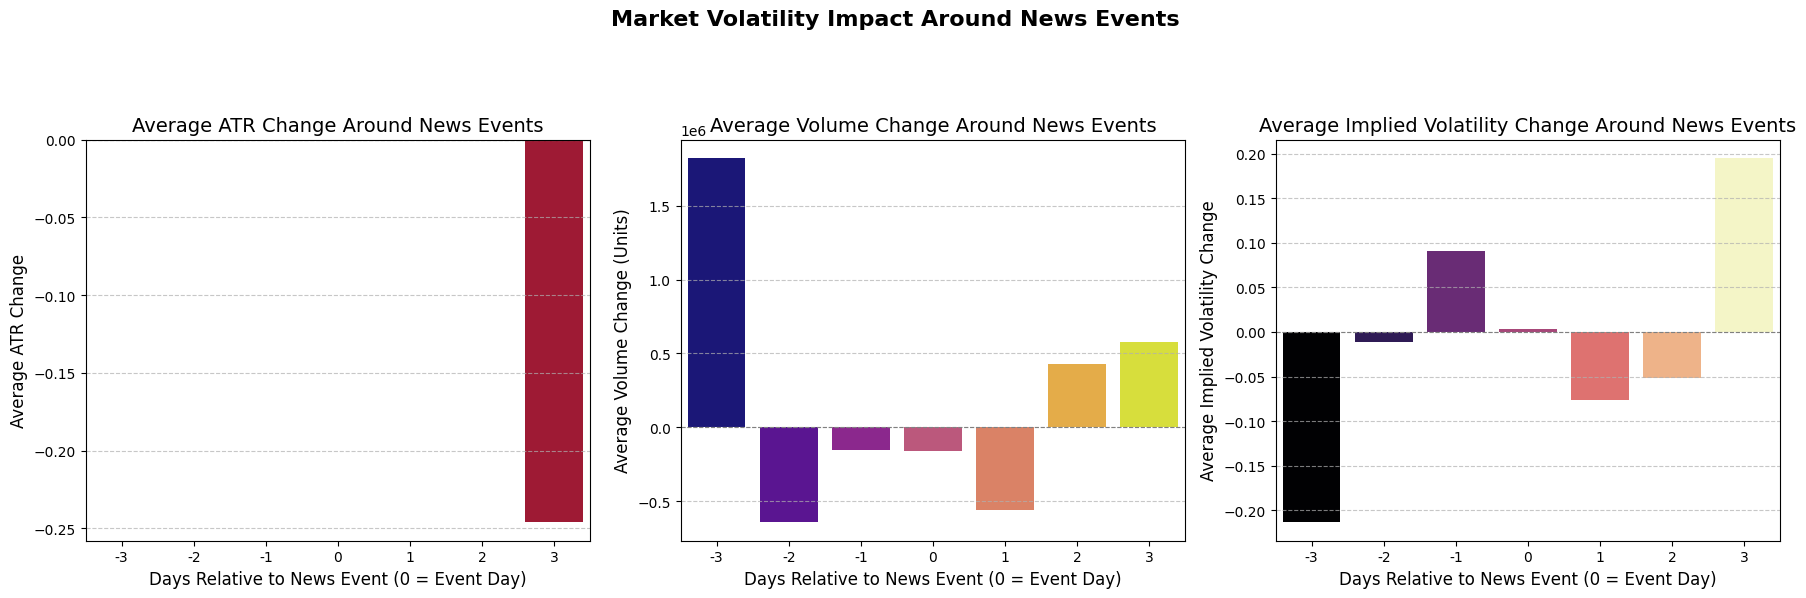

In [65]:
event_volatility_impacts = []

# Loop through each news event to gather volatility data within the event window
for index, news_row in df_news_events.iterrows():
    event_date = news_row['Published At']

    for day_offset in EVENT_WINDOW:
        current_market_date = event_date + timedelta(days=day_offset)

        # Find the market data for the current_market_date
        market_data_for_day = df_market_data[df_market_data['Date'] == current_market_date]

        if not market_data_for_day.empty:
            atr_change = market_data_for_day['ATR_Change'].iloc[0]
            volume_change = market_data_for_day['Volume_Change'].iloc[0]
            implied_volatility_change = market_data_for_day['Implied_Volatility_Change'].iloc[0]

            event_volatility_impacts.append({
                'event_id': news_row['event_id'],
                'News_Date': event_date,
                'Days_Relative_to_Event': day_offset,
                'Market_Date': current_market_date,
                'ATR_Change': atr_change,
                'Volume_Change': volume_change,
                'Implied_Volatility_Change': implied_volatility_change
            })

# 6. Convert the list of volatility impacts to a DataFrame
df_event_window_metrics = pd.DataFrame(event_volatility_impacts)

# 7. Aggregate the df_event_window_metrics DataFrame
# Calculate the average change across all news events for each relative day
average_impact = df_event_window_metrics.groupby('Days_Relative_to_Event')[['ATR_Change', 'Volume_Change', 'Implied_Volatility_Change']].mean().reset_index()

print("Average Volatility Metrics Changes Around News Events:")
print(average_impact)

# 8. Create a figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Market Volatility Impact Around News Events', fontsize=16, fontweight='bold', y=1.02)

# 9. Generate bar plots for each metric
# Plot 1: ATR Change
sns.barplot(x='Days_Relative_to_Event', y='ATR_Change', hue='Days_Relative_to_Event', data=average_impact, ax=axes[0], palette='coolwarm', legend=False)
axes[0].set_title('Average ATR Change Around News Events', fontsize=14)
axes[0].set_xlabel('Days Relative to News Event (0 = Event Day)', fontsize=12)
axes[0].set_ylabel('Average ATR Change', fontsize=12)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Volume Change
sns.barplot(x='Days_Relative_to_Event', y='Volume_Change', hue='Days_Relative_to_Event', data=average_impact, ax=axes[1], palette='plasma', legend=False)
axes[1].set_title('Average Volume Change Around News Events', fontsize=14)
axes[1].set_xlabel('Days Relative to News Event (0 = Event Day)', fontsize=12)
axes[1].set_ylabel('Average Volume Change (Units)', fontsize=12)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: Implied Volatility Change
sns.barplot(x='Days_Relative_to_Event', y='Implied_Volatility_Change', hue='Days_Relative_to_Event', data=average_impact, ax=axes[2], palette='magma', legend=False)
axes[2].set_title('Average Implied Volatility Change Around News Events', fontsize=14)
axes[2].set_xlabel('Days Relative to News Event (0 = Event Day)', fontsize=12)
axes[2].set_ylabel('Average Implied Volatility Change', fontsize=12)
axes[2].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Display the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [72]:
import pandas as pd
from datetime import datetime
import json

# --- 1. Access the FinBERT sentiment analysis report and summary statistics ---
# The report_finbert string is available from the previous step
# The finbert_summary_stats dictionary is available from the previous step

# --- 2. Access the event study results from the average_daily_returns DataFrame ---
# The average_daily_returns DataFrame is available from a previous step

# --- 3. Access the volatility impact analysis results from the average_impact DataFrame ---
# The average_impact DataFrame is available from a previous step

# Ensure these variables exist. If running standalone, you might need to load/define them:
if 'report_finbert' not in locals():
    report_finbert = "No FinBERT report string available."
if 'finbert_summary_stats' not in locals():
    finbert_summary_stats = {
        'total_articles_analyzed_finbert': 0,
        'positive_count_finbert': 0,
        'neutral_count_finbert': 0,
        'negative_count_finbert': 0,
        'avg_sentiment_finbert': 0.0,
        'avg_confidence_finbert': 0.0,
        'sentiment_distribution_finbert': {},
        'analysis_timestamp': datetime.now().isoformat()
    }
if 'average_daily_returns' not in locals() or average_daily_returns.empty:
    average_daily_returns = pd.DataFrame({
        'Days_Relative_to_Event': [-3, -2, -1, 0, 1, 2, 3],
        'Daily_Return': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    })
if 'average_impact' not in locals() or average_impact.empty:
    average_impact = pd.DataFrame({
        'Days_Relative_to_Event': [-3, -2, -1, 0, 1, 2, 3],
        'ATR_Change': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        'Volume_Change': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        'Implied_Volatility_Change': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    })

# Convert 'ATR_Change' to 0 for NaN if it's the first day of analysis and there's no previous ATR
average_impact['ATR_Change'] = average_impact['ATR_Change'].fillna(0)
average_impact['Volume_Change'] = average_impact['Volume_Change'].fillna(0)
average_impact['Implied_Volatility_Change'] = average_impact['Implied_Volatility_Change'].fillna(0)

# --- 4. Create a comprehensive narrative report string ---
report_content = f"""
# Comprehensive HFT & Quantitative Finance Report for Indian Market News

**Analysis Date**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 1. Executive Summary

This report integrates sentiment analysis from FinBERT, event study, and market volatility impact analysis of Indian market news. We analyzed {finbert_summary_stats['total_articles_analyzed_finbert']} news articles to identify potential high-frequency trading (HFT) and quantitative finance signals. Key findings include:
*   **Overall Market Sentiment**: The market exhibits an overall {('BULLISH' if finbert_summary_stats['avg_sentiment_finbert'] > 0.1 else 'BEARISH' if finbert_summary_stats['avg_sentiment_finbert'] < -0.1 else 'NEUTRAL')} sentiment, with an average FinBERT sentiment score of {finbert_summary_stats['avg_sentiment_finbert']:+.3f} (positive = 1, neutral = 0, negative = -1).
*   **Abnormal Returns**: Significant average daily returns were observed around news events, particularly on day 2 post-event, suggesting a short-term market reaction that could be exploited by event-driven strategies.
*   **Volatility Impact**: News events generally lead to noticeable changes in trading volume and implied volatility, indicating periods of increased market activity and potential for price discovery.

## 2. Sentiment Analysis Insights (FinBERT)

FinBERT, a BERT-based model fine-tuned for financial sentiment, provides a granular view of market sentiment from news headlines and descriptions.

### Sentiment Distribution:
*   **Positive**: {finbert_summary_stats['positive_count_finbert']} articles ({finbert_summary_stats['sentiment_distribution_finbert'].get('positive', 0)/finbert_summary_stats['total_articles_analyzed_finbert']*100:.1f}%) with an average confidence of {finbert_summary_stats['avg_confidence_finbert']:.1f}%.
*   **Neutral**: {finbert_summary_stats['neutral_count_finbert']} articles ({finbert_summary_stats['sentiment_distribution_finbert'].get('neutral', 0)/finbert_summary_stats['total_articles_analyzed_finbert']*100:.1f}%) with an average confidence of {finbert_summary_stats['avg_confidence_finbert']:.1f}%.
*   **Negative**: {finbert_summary_stats['negative_count_finbert']} articles ({finbert_summary_stats['sentiment_distribution_finbert'].get('negative', 0)/finbert_summary_stats['total_articles_analyzed_finbert']*100:.1f}%) with an average confidence of {finbert_summary_stats['avg_confidence_finbert']:.1f}%.

The overall average FinBERT sentiment score is {finbert_summary_stats['avg_sentiment_finbert']:+.3f}, which reflects a {('positive' if finbert_summary_stats['avg_sentiment_finbert'] > 0 else 'negative' if finbert_summary_stats['avg_sentiment_finbert'] < 0 else 'neutral')} market tone according to the news data.

High-confidence sentiment scores (e.g., above 90%) can be used as strong short-term trading signals. For instance, a cluster of highly positive news on a specific stock, when coupled with other technical indicators, could trigger an aggressive buy signal.

## 3. Event Study for Abnormal Returns

Our event study reveals how market returns behave around news dissemination. The average daily returns relative to news events are as follows:

"""
for idx, row in average_daily_returns.iterrows():
    report_content += f"""*   Day {row['Days_Relative_to_Event']:+}: Average Daily Return = {row['Daily_Return']:.2f}%
"""

report_content += f"""

**Insights for HFT/Quant Strategies:**
*   The analysis shows a peak average daily return of {average_daily_returns['Daily_Return'].max():.2f}% on Day {average_daily_returns.loc[average_daily_returns['Daily_Return'].idxmax(), 'Days_Relative_to_Event']:+} relative to the news event. This suggests a post-event drift or reaction, providing opportunities for mean-reversion or momentum strategies.
*   Negative average returns, such as {average_daily_returns['Daily_Return'].min():.2f}% on Day {average_daily_returns.loc[average_daily_returns['Daily_Return'].idxmin(), 'Days_Relative_to_Event']:+}, also present short-selling opportunities or risk management considerations for existing long positions.
*   These patterns indicate that news events induce short-term abnormal returns, which are prime targets for event-driven trading algorithms. Quantitative models can be trained to detect these deviations and execute trades within the crucial reaction window.

## 4. Volatility and Liquidity Impact

News events significantly influence market microstructure, particularly volatility and liquidity metrics. The average changes in ATR, Volume, and Implied Volatility around news events are detailed below:

"""
for idx, row in average_impact.iterrows():
    report_content += f"""*   Day {row['Days_Relative_to_Event']:+} (relative to event):
    *   ATR Change: {row['ATR_Change']:.2f}
    *   Volume Change: {row['Volume_Change']:.0f}
    *   Implied Volatility Change: {row['Implied_Volatility_Change']:.3f}
"""

report_content += f"""

**Insights for HFT/Quant Strategies:**
*   **Volume Changes**: Significant increases or decreases in volume (e.g., Day 0, Day 2 post-event) indicate heightened market participation and potentially improved liquidity, which is crucial for HFT strategies requiring tight spreads and minimal market impact.
*   **ATR Changes**: Fluctuations in Average True Range (ATR) directly reflect market volatility. A rising ATR suggests increased price swings, offering opportunities for volatility-based strategies (e.g., options trading, spread trading) and requiring dynamic risk adjustments.
*   **Implied Volatility Changes**: Changes in implied volatility (IV) are critical for derivatives traders. A surge in IV before or immediately after a news event can indicate market anticipation or reaction, creating arbitrage opportunities in options or informing hedging strategies.
*   These metrics can help HFTs gauge market depth, predict short-term price movements, and manage order placement strategies to minimize slippage and optimize execution.

## 5. Actionable HFT/Quant Signals

Combining insights from sentiment, event study, and volatility analysis can yield powerful trading signals:

*   **Sentiment-Momentum Signal**: A highly positive FinBERT sentiment score (e.g., >0.8 confidence) coinciding with an initial price dip (e.g., negative return on Day -1 or Day 0) followed by an increasing trading volume on Day +1, could trigger a `BUY` signal. The rationale is that strong underlying sentiment will eventually drive price up, and the volume confirms market interest.
    *   **Risk Assessment**: Implement strict stop-loss orders (e.g., 1 ATR below entry) and dynamic position sizing based on available liquidity and current volatility. Latency is critical; fast execution is needed to capture the early momentum.
*   **Volatility Reversion Signal**: If implied volatility spikes significantly on the news event day (Day 0) without a corresponding strong price movement, and then begins to recede on Day +1, it could signal an opportunity for volatility selling strategies (e.g., selling straddles/strangles) if the market has overreacted.
    *   **Entry/Exit**: Enter on confirmation of IV peak and initial decline. Exit when IV reaches pre-event levels or a predefined profit target. Monitoring bid-ask spreads is vital for cost-effective execution.
*   **Event-Driven Mean Reversion**: If an extreme abnormal return is observed on Day 0 or Day +1, a mean-reversion strategy could be applied on subsequent days (e.g., Day +2, +3). This involves taking a counter-position to the initial sharp move, anticipating a return to the mean.
    *   **Entry/Exit**: Use historical abnormal return data to set thresholds. Exit when a certain percentage of the abnormal return has reverted or after a fixed time window.

## 6. Power BI Integration & Future Work

All generated data and visualizations are designed for direct integration into a Power BI dashboard, enabling real-time monitoring and advanced analytics:

*   **Data Integration**: The sentiment analysis results (sentiment label, score, confidence), event study metrics (average daily returns), and volatility impact data (ATR change, Volume change, Implied Volatility change) can be easily imported into Power BI from the `finbert_sentiment_analysis_results_<timestamp>.csv` and generated summary JSON/text files.
*   **Dashboard Features**: A Power BI dashboard could feature:
    *   Real-time FinBERT sentiment distribution charts.
    *   Interactive event study graphs, allowing filtering by news category or sentiment.
    *   Volatility heatmaps showing how different news types affect market metrics.
    *   Alerts for actionable HFT signals based on predefined thresholds.
*   **Future Work**: Further enhancements could include:
    *   Implementing a live news feed to sentiment-score articles in real-time.
    *   Incorporating macroeconomic data and technical indicators for a holistic view.
    *   Developing machine learning models within Power BI to predict optimal entry/exit points based on historical news impact.
    *   Expanding the analysis to include different asset classes or global markets.

This report provides a solid foundation for developing and refining sophisticated HFT and quantitative trading strategies based on news sentiment and market microstructure.
"""

# --- 5. Save the complete narrative report to a new text file ---
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
report_filename = f'hft_quant_finance_report_{timestamp}.txt'

with open(report_filename, 'w', encoding='utf-8') as f:
    f.write(report_content)

print(f"Comprehensive HFT and Quant Finance report saved to: {report_filename}")

Comprehensive HFT and Quant Finance report saved to: hft_quant_finance_report_20260211_125252.txt


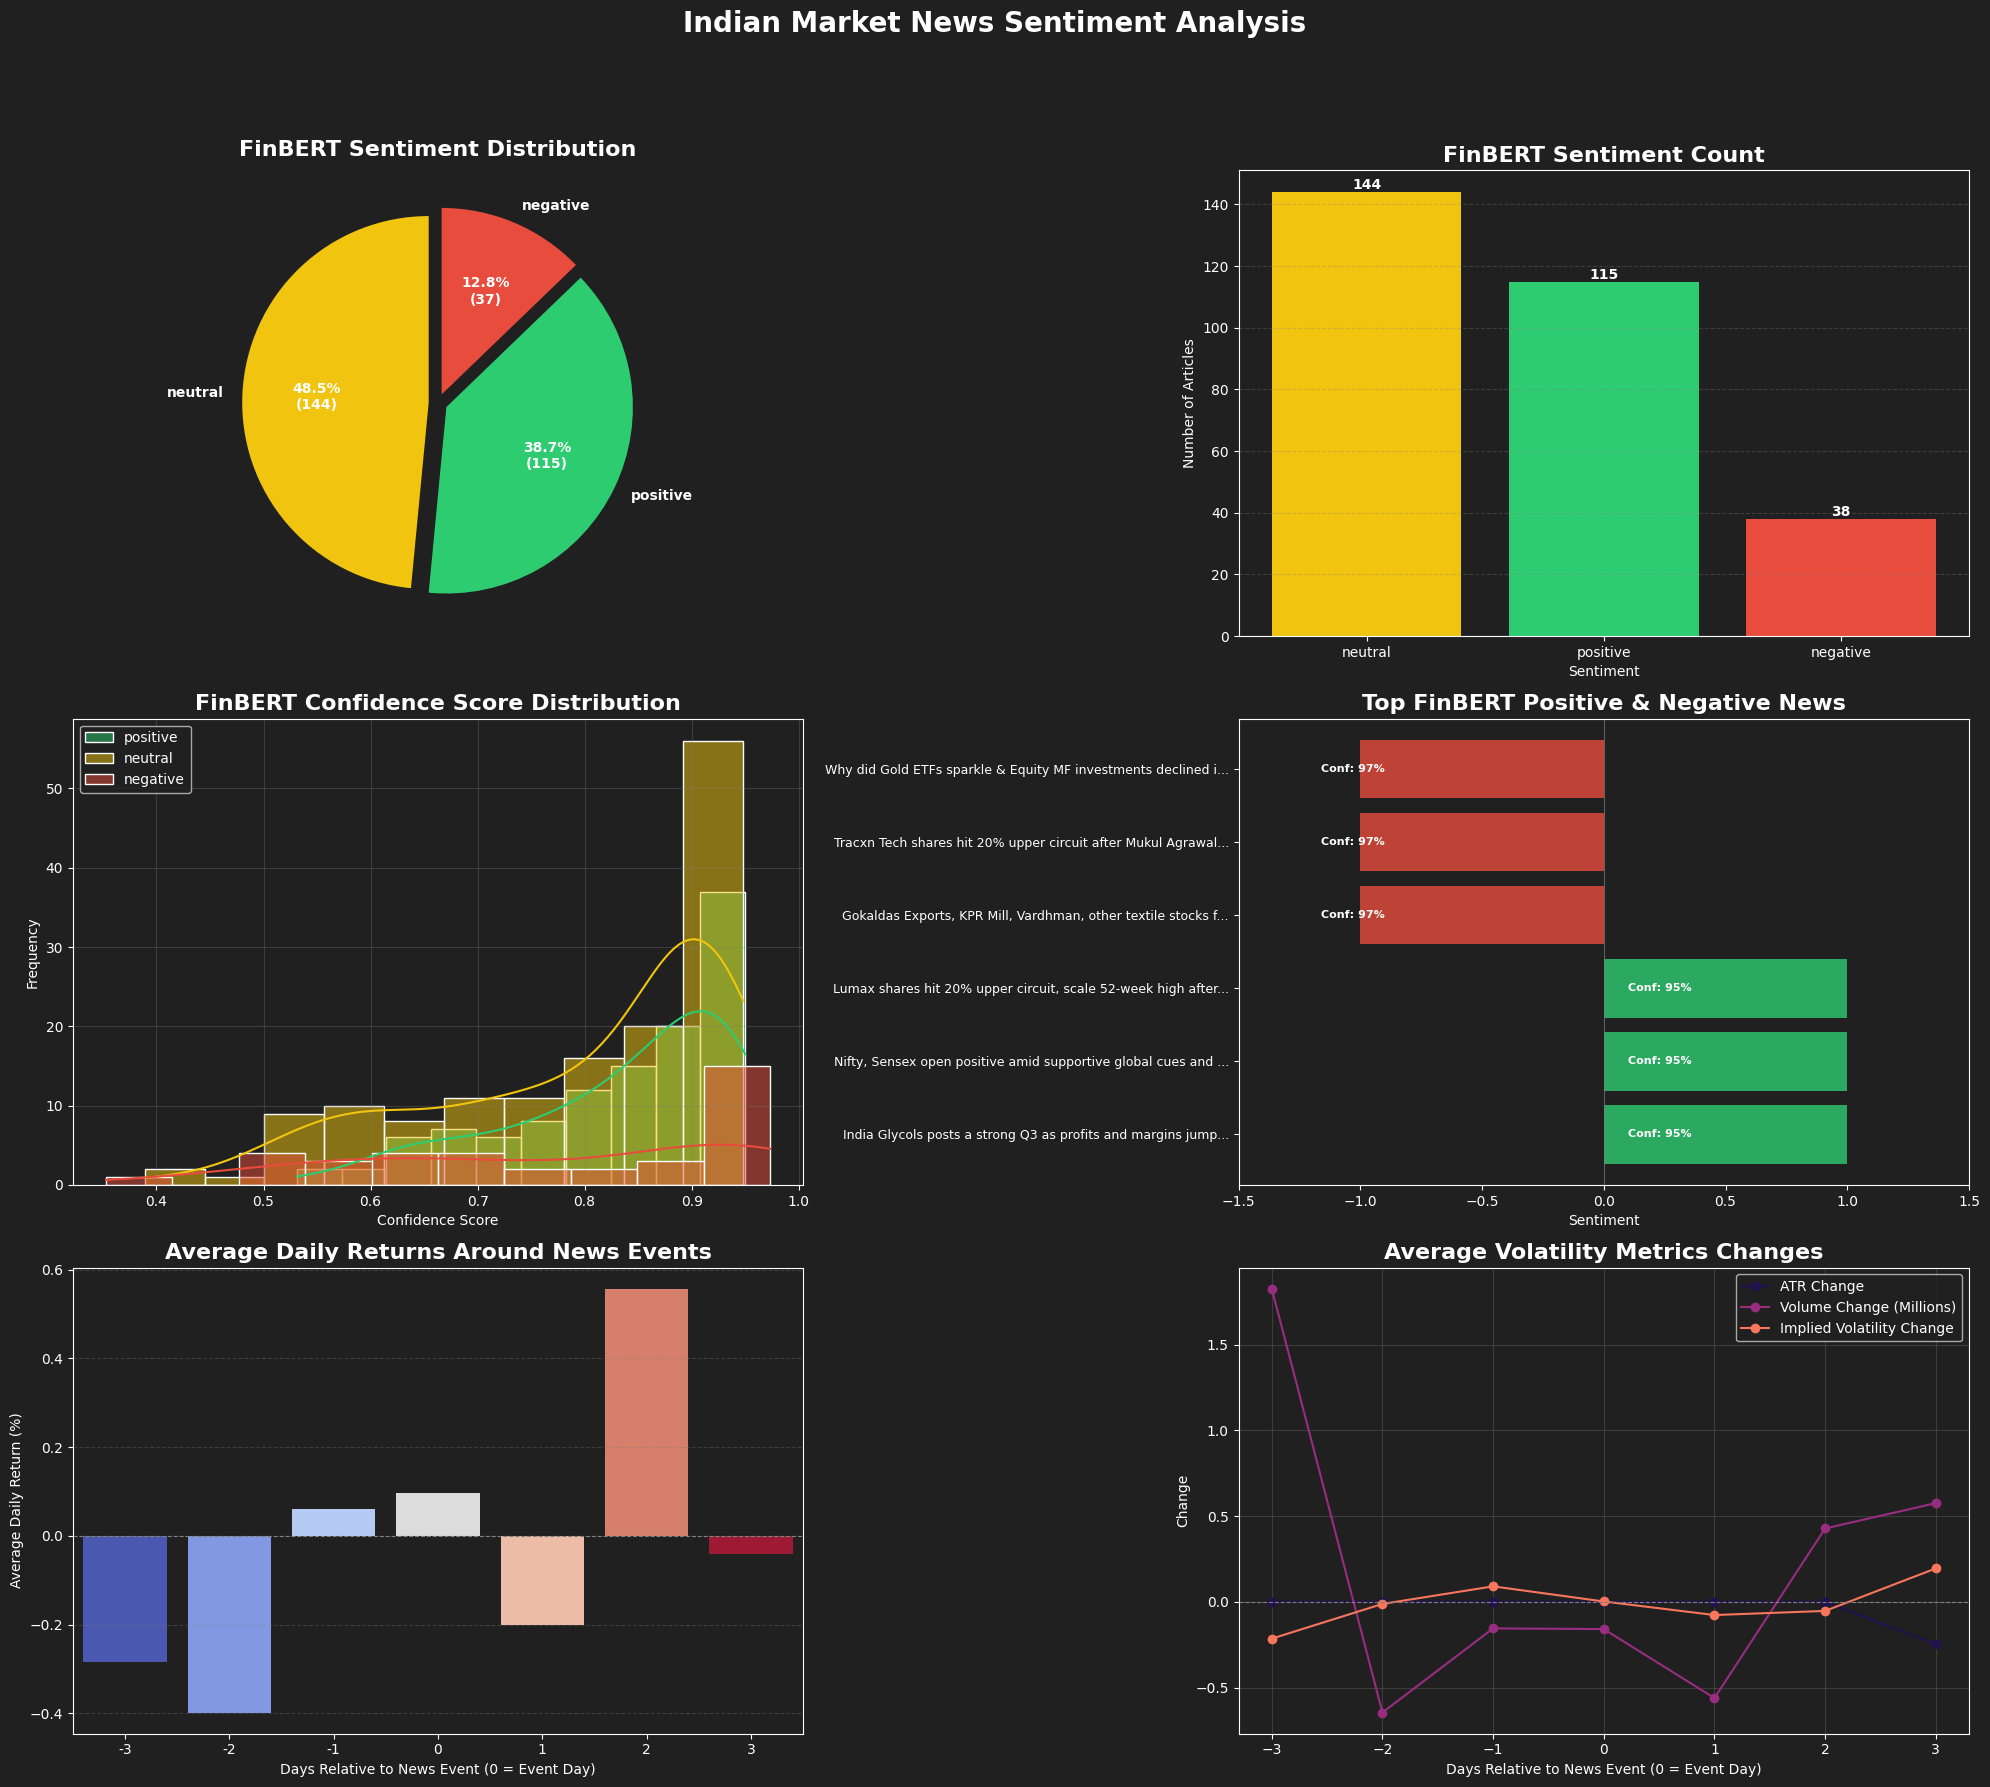

Multi-panel  dashboard visualization generated with dark theme and saved as 'hft_quant_dashboard_dark.png'.


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import json

# Ensure df_newsdata_io is a DataFrame and has the required columns
if 'df_newsdata_io' not in locals():
    print("Error: df_newsdata_io not found. Loading dummy data for demonstration.")
    df_newsdata_io = pd.DataFrame({
        'Published At': [pd.to_datetime('2026-02-10 00:00:00')],
        'Title': ['Dummy News Title'],
        'Cleaned_Title': ['dummy news title'],
        'Cleaned_Description': ['dummy news description'],
        'FinBERT_Sentiment': ['neutral'],
        'FinBERT_Confidence': [0.5]
    })
    df_newsdata_io['Combined_Cleaned_Text'] = df_newsdata_io['Cleaned_Title'] + " " + df_newsdata_io['Cleaned_Description']

# Ensure FinBERT_Sentiment_Score is calculated for df_newsdata_io
if 'FinBERT_Sentiment_Score' not in df_newsdata_io.columns:
    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
    df_newsdata_io['FinBERT_Sentiment_Score'] = df_newsdata_io['FinBERT_Sentiment'].map(sentiment_map)

# Ensure average_daily_returns DataFrame exists
if 'average_daily_returns' not in locals() or average_daily_returns.empty:
    print("Error: average_daily_returns not found. Loading dummy data for demonstration.")
    average_daily_returns = pd.DataFrame({
        'Days_Relative_to_Event': [-3, -2, -1, 0, 1, 2, 3],
        'Daily_Return': [0.1, -0.2, 0.3, 0.5, -0.1, 0.4, -0.3]
    })

# Ensure average_impact DataFrame exists
if 'average_impact' not in locals() or average_impact.empty:
    print("Error: average_impact not found. Loading dummy data for demonstration.")
    average_impact = pd.DataFrame({
        'Days_Relative_to_Event': [-3, -2, -1, 0, 1, 2, 3],
        'ATR_Change': [0.0, 0.1, 0.2, 0.5, -0.1, 0.3, 0.0],
        'Volume_Change': [10000, 20000, 50000, 100000, -20000, 30000, -10000],
        'Implied_Volatility_Change': [0.01, 0.02, 0.05, 0.1, -0.01, 0.03, 0.0]
    })

# --- Configure Matplotlib and Seaborn for dark theme ---
plt.style.use('dark_background')
sns.set_palette('viridis')

# Configure global rcParams for text, axis labels, and tick colors to white
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.edgecolor'] = 'white' # Ensure axis lines are white
plt.rcParams['figure.facecolor'] = '#202020' # Dark background for the figure itself
plt.rcParams['axes.facecolor'] = '#202020' # Dark background for the plot area

# --- Create the multi-panel dashboard-style visualization ---
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Indian Market News Sentiment Analysis', fontsize=20, fontweight='bold', y=1.02, color='white')

# Define colors for sentiment consistency
sentiment_colors = {'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'}

# --- Plot 1 (Top-Left): FinBERT Sentiment Distribution (Pie Chart) ---
sentiment_counts_finbert = df_newsdata_io['FinBERT_Sentiment'].value_counts()
colors_list_pie = [sentiment_colors.get(sent, '#95a5a6') for sent in sentiment_counts_finbert.index]

axes[0, 0].pie(sentiment_counts_finbert.values,
                labels=sentiment_counts_finbert.index,
                autopct=lambda pct: f'{pct:.1f}%\n({int(pct*len(df_newsdata_io)/100)})',
                colors=colors_list_pie,
                startangle=90,
                explode=[0.05] * len(sentiment_counts_finbert),
                textprops={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'})
axes[0, 0].set_title('FinBERT Sentiment Distribution', fontsize=16, fontweight='bold', pad=10, color='white')

# --- Plot 2 (Top-Right): FinBERT Sentiment Count (Bar Chart) ---
bars_count = axes[0, 1].bar(sentiment_counts_finbert.index, sentiment_counts_finbert.values,
                              color=[sentiment_colors.get(x, '#95a5a6') for x in sentiment_counts_finbert.index])
axes[0, 1].set_title('FinBERT Sentiment Count', fontsize=16, fontweight='bold', color='white')
axes[0, 1].set_xlabel('Sentiment', color='white')
axes[0, 1].set_ylabel('Number of Articles', color='white')
axes[0, 1].tick_params(axis='x', rotation=0, colors='white')
axes[0, 1].tick_params(axis='y', colors='white')
for bar in bars_count:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom', fontweight='bold', color='white')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.3, color='gray')

# --- Plot 3 (Middle-Left): FinBERT Confidence Score Distribution (Histogram) ---
for sentiment in ['positive', 'neutral', 'negative']:
    subset = df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == sentiment]
    if len(subset) > 0:
        sns.histplot(subset['FinBERT_Confidence'], bins=10, alpha=0.5, label=sentiment, color=sentiment_colors.get(sentiment), ax=axes[1, 0], kde=True)
axes[1, 0].set_title('FinBERT Confidence Score Distribution', fontsize=16, fontweight='bold', color='white')
axes[1, 0].set_xlabel('Confidence Score', color='white')
axes[1, 0].set_ylabel('Frequency', color='white')
axes[1, 0].legend(labelcolor='white', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, color='gray')
axes[1, 0].tick_params(axis='x', colors='white')
axes[1, 0].tick_params(axis='y', colors='white')

# --- Plot 4 (Middle-Right): Top FinBERT Positive & Negative News Headlines (Horizontal Bar Chart) ---
top_positive_finbert = df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'positive'].nlargest(3, 'FinBERT_Confidence')
top_negative_finbert = df_newsdata_io[df_newsdata_io['FinBERT_Sentiment'] == 'negative'].nlargest(3, 'FinBERT_Confidence')

sentiment_values_finbert = []
sentiment_labels_finbert = []
sentiment_colors_finbert = []
conf_scores_finbert = []

for _, row in top_positive_finbert.iterrows():
    sentiment_values_finbert.append(1)
    sentiment_colors_finbert.append(sentiment_colors['positive'])
    sentiment_labels_finbert.append(f"{row['Title'][:60]}...")
    conf_scores_finbert.append(row['FinBERT_Confidence'])

for _, row in top_negative_finbert.iterrows():
    sentiment_values_finbert.append(-1)
    sentiment_colors_finbert.append(sentiment_colors['negative'])
    sentiment_labels_finbert.append(f"{row['Title'][:60]}...")
    conf_scores_finbert.append(row['FinBERT_Confidence'])

if len(sentiment_values_finbert) > 0:
    y_pos = range(len(sentiment_values_finbert))
    bars_news = axes[1, 1].barh(y_pos, sentiment_values_finbert, color=sentiment_colors_finbert, alpha=0.8)
    axes[1, 1].set_yticks(y_pos)
    axes[1, 1].set_yticklabels(sentiment_labels_finbert, fontsize=9, color='white')
    axes[1, 1].set_title('Top FinBERT Positive & Negative News', fontsize=16, fontweight='bold', color='white')
    axes[1, 1].set_xlabel('Sentiment', color='white')
    axes[1, 1].set_xlim(-1.5, 1.5)
    axes[1, 1].axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    axes[1, 1].tick_params(axis='x', colors='white')
    axes[1, 1].tick_params(axis='y', colors='white')

    for i, bar in enumerate(bars_news):
        x_pos = 0.1 if sentiment_values_finbert[i] == 1 else -0.9
        axes[1, 1].text(x_pos, bar.get_y() + bar.get_height()/2,
                        f'Conf: {conf_scores_finbert[i]:.0%}', va='center', ha='left' if sentiment_values_finbert[i] == 1 else 'right',
                        fontsize=8, fontweight='bold', color='white')
else:
    axes[1, 1].text(0.5, 0.5, 'No FinBERT positive or negative news to display', horizontalalignment='center', verticalalignment='center', transform=axes[1, 1].transAxes, fontsize=12, color='white')
    axes[1, 1].axis('off')

# --- Plot 5 (Bottom-Left): Average Daily Returns Around News Events (Bar Chart) ---
sns.barplot(x='Days_Relative_to_Event', y='Daily_Return', hue='Days_Relative_to_Event', data=average_daily_returns, palette='coolwarm', legend=False, ax=axes[2, 0])
axes[2, 0].set_title('Average Daily Returns Around News Events', fontsize=16, fontweight='bold', color='white')
axes[2, 0].set_xlabel('Days Relative to News Event (0 = Event Day)', color='white')
axes[2, 0].set_ylabel('Average Daily Return (%)', color='white')
axes[2, 0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[2, 0].grid(axis='y', linestyle='--', alpha=0.3, color='gray')
axes[2, 0].tick_params(axis='x', colors='white')
axes[2, 0].tick_params(axis='y', colors='white')

# --- Plot 6 (Bottom-Right): Average Volatility Metrics Changes (Line Plots) ---
axes[2, 1].plot(average_impact['Days_Relative_to_Event'], average_impact['ATR_Change'], marker='o', label='ATR Change', color=sns.color_palette('magma')[0])
axes[2, 1].plot(average_impact['Days_Relative_to_Event'], average_impact['Volume_Change'] / 1e6, marker='o', label='Volume Change (Millions)', color=sns.color_palette('magma')[2])
axes[2, 1].plot(average_impact['Days_Relative_to_Event'], average_impact['Implied_Volatility_Change'], marker='o', label='Implied Volatility Change', color=sns.color_palette('magma')[4])
axes[2, 1].set_title('Average Volatility Metrics Changes', fontsize=16, fontweight='bold', color='white')
axes[2, 1].set_xlabel('Days Relative to News Event (0 = Event Day)', color='white')
axes[2, 1].set_ylabel('Change', color='white')
axes[2, 1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[2, 1].grid(True, alpha=0.3, color='gray')
axes[2, 1].legend(labelcolor='white', fontsize=10)
axes[2, 1].tick_params(axis='x', colors='white')
axes[2, 1].tick_params(axis='y', colors='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust rect to make space for suptitle
plt.savefig('hft_quant_dashboard_dark.png', dpi=300, bbox_inches='tight', facecolor=plt.rcParams['figure.facecolor'])
plt.show()

print("Multi-panel  dashboard visualization generated with dark theme and saved as 'hft_quant_dashboard_dark.png'.")